## GET request (App)

In [1]:
import requests
import pandas as pd
import streamlit as st
from streamlit_autorefresh import st_autorefresh
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from dashboard.prepare_data import prepare_data
from configs.dashboard_config import API_URL, REFRESH_INTERVAL


# auto refresh every minute
st_autorefresh(
    interval=REFRESH_INTERVAL,
    key="dashboard_refresh",
)


# --- GET request ---
try:
    response = requests.get(API_URL, timeout=10)
    response.raise_for_status()

    data = response.json()

except requests.RequestException as e:
    st.error(f"API unavailable: {e}")
    st.stop()


# --- Prepare data for plotting ---
df_discharge = pd.DataFrame(data["discharge"])
df_inference = pd.DataFrame(data["inference"])
df_precip_obs = pd.DataFrame(data["precip_obs"])
df_precip_pred = pd.DataFrame(data["precip_pred"])

2026-05-27 00:36:55.994 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:36:56.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:36:56.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:36:56.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:36:56.151 
  command:

    streamlit run C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-27 00:36:56.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 00:36:56.155 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [5]:
df_discharge.set_index("timestamp").index.max()

'2026-05-26T23:00:00'

## API

In [6]:
from fastapi import FastAPI

from database.db import SessionLocal 
from database.models import Discharge, Inference
from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data


# Create web application instance -> main backend server object
app = FastAPI()

# Decorator -> when sb. GET requests to /forecast -> run function:
# When streamlit do requests.get() -> get_forecast() is executed.
@app.get("/forecast")

def get_forecast():
    df_discharge = load_discharge_data()
    df_inference = load_inference_data()
    df_precip_obs = load_precip_observation_data()
    df_precip_pred = load_precip_forecast_data()

get_forecast()


In [14]:
df_discharge.tail(1)

,timestamp,discharge
1337,2026-05-26T23:00:00,0.733


## Inference ingestion

In [ ]:
from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data
from jobs.inference.ingest_inference import merge_data, create_inference_features, run_inference, build_forecast_dataframe, write_to_db

In [10]:
discharge = load_discharge_data(days=3)
precip_observation = load_precip_observation_data(days=3)
# discharge.tail(1)
print(discharge.index.max())
print(precip_observation.index.max())

2026-05-26 23:30:00
2026-05-25 23:45:00


In [11]:
dfs = [discharge, precip_observation]
merged = merge_data(dfs=dfs)
merged.index.max()

Timestamp('2026-05-26 23:30:00')

In [12]:
features = create_inference_features(df=merged)
features.index.max()

Timestamp('2026-05-26 23:30:00')

In [13]:
inference = run_inference(df=features)
inference

array([0.9418523], dtype=float32)

In [54]:
df_inference = build_forecast_dataframe(
        preds=inference,
        history_index=features.index,
        freq="15min"
    )
df_inference.index.max()

Timestamp('2026-05-26 23:45:00')

In [55]:
write_to_db(df_inference)

2026-05-27 00:47:54,182 | ingest_inference.py | INFO | [INFERENCE] Inserted 1 rows.


In [56]:
inference_query = load_inference_data()
inference_query.index.max()

Timestamp('2026-05-26 23:45:00')

## Hampel filter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing.filtering import hampel_filter

In [6]:
discharge = load_discharge_data(days=30)

In [3]:
# def hampel_filter(
#     series, 
#     window=5, 
#     n_sigmas=3
#     ):
    
#     rolling_median = series.rolling(window, center=True).median()
#     mad = (series - rolling_median).abs().rolling(window, center=True).median()

#     threshold = n_sigmas * 1.4826 * mad
#     outlier = (series - rolling_median).abs() > threshold

#     return series.mask(outlier, rolling_median)


def hampel_and_ma(df):
    df = hampel_filter(df)
    df = df.rolling(5).mean()
    
    return df

def hampel_and_ewm(df):
    df = hampel_filter(df)
    df = df.ewm(span=3).mean()
    
    return df

In [1]:
hampel_filter(discharge).index

NameError: name 'hampel_filter' is not defined

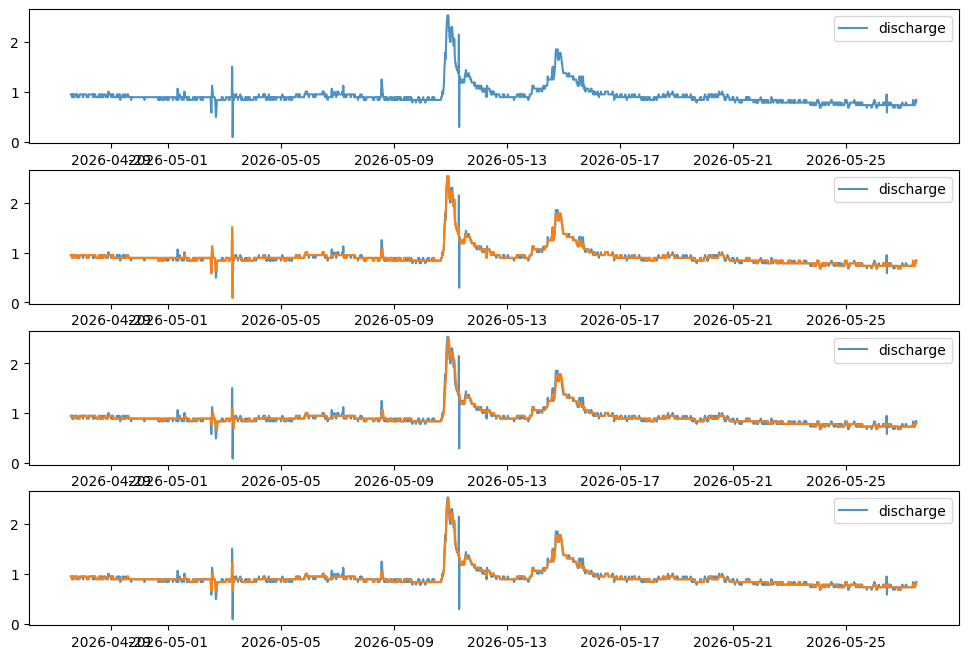

In [ ]:
fig, ax = plt.subplots(figsize=(12,8), nrows=4)

for i in range(4):
    ax[i].plot(discharge, label="discharge", alpha = 0.8)
    ax[i].legend()

ax[1].plot(hampel_filter(discharge), label="hampeled")
ax[2].plot(hampel_and_ma(discharge), label="hampel & ma")
ax[3].plot(hampel_and_ewm(discharge), label="hampeled & ewm")

plt.show()